In [17]:
pip install requests beautifulsoup4 pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [18]:
import requests, bs4, pandas, matplotlib
print("Todo OK")

Todo OK


In [19]:
import requests
from bs4 import BeautifulSoup

url = "https://books.toscrape.com/"
response = requests.get(url)

In [20]:
#Comprueba que todo fue bien,
print(response.status_code)  # debe imprimir 200
print(response.text[:500])    # primeros 500 chars del HTML

200
<!DOCTYPE html>
<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->
    <head>
        <title>
    All products | Books to Scrape - Sandbox
</title>

        <meta http-equiv="content-type" content="text/html; charset=UTF-8" /


In [21]:
soup = BeautifulSoup(response.text, "html.parser")
print(soup.title.text)  # imprime el título de la página


    All products | Books to Scrape - Sandbox



### Seleccionar todos los libros

In [22]:
rating_map = {"One":1, "Two":2, "Three":3,
               "Four":4, "Five":5}
libros = []

for art in soup.select("article.product_pod"):
    titulo = art.select_one("h3 a")["title"]
    precio = art.select_one("p.price_color").text.strip()
    r_clase = art.select_one("p.star-rating")["class"][1]
    rating  = rating_map.get(r_clase, 0)
    stock   = art.select_one("p.availability").text.strip()

    libros.append({
        "titulo": titulo,
        "precio": precio,
        "rating": rating,
        "stock": stock
    })

print(f"Extraídos {len(libros)} libros")
print(libros[0])



Extraídos 20 libros
{'titulo': 'A Light in the Attic', 'precio': 'Â£51.77', 'rating': 3, 'stock': 'In stock'}


### Scraping de todas las páginas

In [23]:
import time

BASE = "https://books.toscrape.com/catalogue/"
url  = "https://books.toscrape.com/catalogue/page-1.html"
todos = []

while url:
    r = requests.get(url)
    soup = BeautifulSoup(r.text, "html.parser")

    for art in soup.select("article.product_pod"):
        titulo = art.select_one("h3 a")["title"]
        precio = art.select_one("p.price_color").text.strip()
        r_clase = art.select_one("p.star-rating")["class"][1]
        rating  = rating_map.get(r_clase, 0)
        stock   = art.select_one("p.availability").text.strip()

        todos.append({
            "titulo": titulo,
            "precio": precio,
            "rating": rating,
            "stock": stock
    })
        
# busca el enlace "next",
    sig = soup.select_one("li.next a")
    url = BASE + sig["href"] if sig else None
    time.sleep(0.5)  # pausa entre peticiones

print(f"Total: {len(todos)} libros")  # debe dar 1000    

Total: 1000 libros


### Exportar datos a csv

In [24]:
import pandas as pd

df = pd.DataFrame(todos)

# Limpia el precio: "Â£51.77" → 51.77,
df["precio_num"] = (df["precio"]
    .str.replace(r"[^\d.]", "", regex=True)
    .astype(float))

print(df.head())
print(df.describe())

#Guardar,
df.to_csv("libros2.csv", index=False, encoding="utf-8-sig")
print(" Guardado en libros2.csv")

                                  titulo   precio  rating     stock  \
0                   A Light in the Attic  Â£51.77       3  In stock   
1                     Tipping the Velvet  Â£53.74       1  In stock   
2                             Soumission  Â£50.10       1  In stock   
3                          Sharp Objects  Â£47.82       4  In stock   
4  Sapiens: A Brief History of Humankind  Â£54.23       5  In stock   

   precio_num  
0       51.77  
1       53.74  
2       50.10  
3       47.82  
4       54.23  
            rating  precio_num
count  1000.000000  1000.00000
mean      2.923000    35.07035
std       1.434967    14.44669
min       1.000000    10.00000
25%       2.000000    22.10750
50%       3.000000    35.98000
75%       4.000000    47.45750
max       5.000000    59.99000
 Guardado en libros2.csv


In [25]:
display(df.head())

,titulo,precio,rating,stock,precio_num
0,A Light in the Attic,Â£51.77,3,In stock,51.77
1,Tipping the Velvet,Â£53.74,1,In stock,53.74
2,Soumission,Â£50.10,1,In stock,50.10
3,Sharp Objects,Â£47.82,4,In stock,47.82
4,Sapiens: A Brief History of Humankind,Â£54.23,5,In stock,54.23


### Analiza y visualiza datos

Precio medio: £35.07
Más caro: The Perfect Play (Play by Play #1)
rating
1    34.56
2    34.81
3    34.69
4    36.09
5    35.37
Name: precio_num, dtype: float64


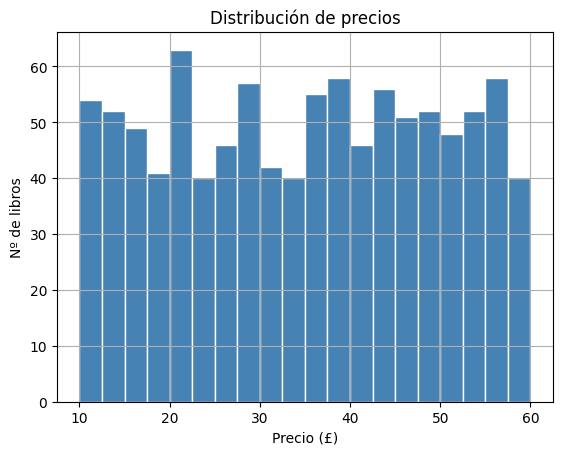

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("libros2.csv")

# Estadísticas básicas,
print(f"Precio medio: £{df['precio_num'].mean():.2f}")
print(f"Más caro: {df.loc[df['precio_num'].idxmax(), 'titulo']}")
print(df.groupby("rating")["precio_num"].mean().round(2))

# Histograma de precios,
df["precio_num"].hist(bins=20, color="steelblue", edgecolor="white")
plt.title("Distribución de precios")
plt.xlabel("Precio (£)")
plt.ylabel("Nº de libros")
plt.savefig("precios.png")
plt.show()

## Consultas libres

###  Consulta 1: 💸 🕮  Me lo quitan de las manos

Vamos a realizar un análisis de valor. En esta consulta buscaremos libros que tengan 4 ó 5 estrellas y cuyo precio sea menor de £20.

In [27]:
# Filtramos libros con rating alto y precio bajo
gangas = df[(df['rating'] >= 4) & (df['precio_num'] < 20)]

print("--- Posibles Gangas (4+ estrellas y < £20) ---")
if not gangas.empty:
    print(gangas[['titulo', 'precio_num', 'rating']])
else:
    print("No se encontraron libros con esos criterios en esta página.")

--- Posibles Gangas (4+ estrellas y < £20) ---
                                                titulo  precio_num  rating
12                                         Set Me Free       17.46       5
30   The Four Agreements: A Practical Guide to Pers...       17.66       5
34                                      Sophie's World       15.94       5
47             Untitled Collection: Sabbath Poems 2014       14.27       4
53                                     This One Summer       19.49       4
..                                                 ...         ...     ...
913                                    The Zombie Room       19.69       5
917                                    The Silent Wife       12.34       5
934                                  The Girl You Lost       12.29       5
937              The Edge of Reason (Bridget Jones #2)       19.18       4
997  A Spy's Devotion (The Regency Spies of London #1)       16.97       5

[75 rows x 3 columns]


### Consulta 2: 🖇 ¿Medimos títulos?

En el marketing del mundo editorial hay teorías que afirman que los títulos cortos vendan más....¿comprobamos si hay relación entre la longitud del título y el precio?

In [28]:
# Creamos una nueva columna con la longitud del título
df['longitud_titulo'] = df['titulo'].apply(len)

print("\n--- Correlación de Pearson entre longitud de título y precio ---")
correlacion = df['longitud_titulo'].corr(df['precio_num'])
print(f"El coeficiente de correlación es: {correlacion:.2f}")
# (Si es cercano a 0, no hay relación; si es cercano a 1 o -1, la hay)


--- Correlación de Pearson entre longitud de título y precio ---
El coeficiente de correlación es: 0.01


La correlación de Pearson entre la longitud del título y el precio es $r = 0.01$, lo que indica que no existe dependencia entre ambas variables. Esto sugiere que la política de precios de la librería no se ve influenciada por factores morfológicos del título, sino probablemente por el género o el contenido del libro...quien lo hubiera pensado, ¿verdad?

### Consulta 3: La longitud del título no influye en la venta pero ¿habrá correlación entre Rating y Precio?

In [29]:
correlacion_rating = df['rating'].corr(df['precio_num'])
print(f"Correlación Pearson Rating-Precio: {correlacion_rating:.2f}")

Correlación Pearson Rating-Precio: 0.03


Y ésto nos indica que esta librería es "inusual": el éxito (estrellas) no tiene nada que ver con el dinero (precio).

#### Gráfico para mostrar la relación entre Rating y Precio 

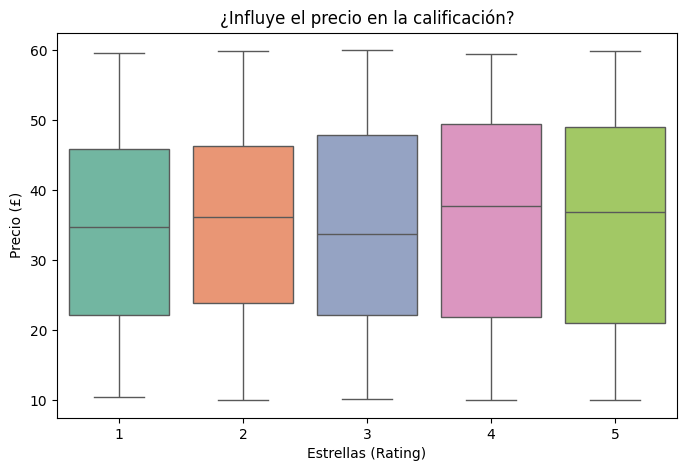

In [30]:
import seaborn as sns # Si no tienes seaborn, puedes usar plt.boxplot

plt.figure(figsize=(8, 5))
sns.boxplot(x='rating', y='precio_num', data=df, palette="Set2", hue='rating', legend=False)
plt.title("¿Influye el precio en la calificación?")
plt.xlabel("Estrellas (Rating)")
plt.ylabel("Precio (£)")
plt.show()

#### ¿Qué nos indica este gráfico?

1. ¿Qué es cada parte de la "caja"?
Imaginemos que ordenamos todos los precios de los libros de 1 estrella de menor a mayor:

La línea horizontal dentro de la caja: Es la Mediana. Divide los datos en dos grupos: el 50% de los libros cuestan menos de ese valor y el otro 50% cuestan más.

La caja (el rectángulo de color): Representa el 50% central de los libros. Es decir, dónde se concentran la mayoría de los precios.

Los "bigotes" (las líneas que salen arriba y abajo): Indican el precio más caro y el más barato de esa categoría (dentro de un rango normal).

2. ¿Cómo leer este gráfico específico?
Las 5 cajas: ¡Son casi iguales!

Alturas similares: Las cajas empiezan y terminan casi en los mismos puntos (entre £20 y £50 aproximadamente).

Medianas alineadas: Si trazamos una línea imaginaria, veremos que las rayitas del centro de las cajas están casi a la misma altura.

Conclusión visual: Esto confirma la 0.03 de correlación. Si el precio influyera en el rating, veríamos que la caja de "5 estrellas" está mucho más arriba que la de "1 estrella". Como están "al mismo nivel", visualmente demuestramos que el precio no tiene nada que ver con la puntuación.

#### Gráfico de dispersión con Línea de Tendencia


Vamos a visualizar ese 0.03 de la correlación entre Rating y Precio

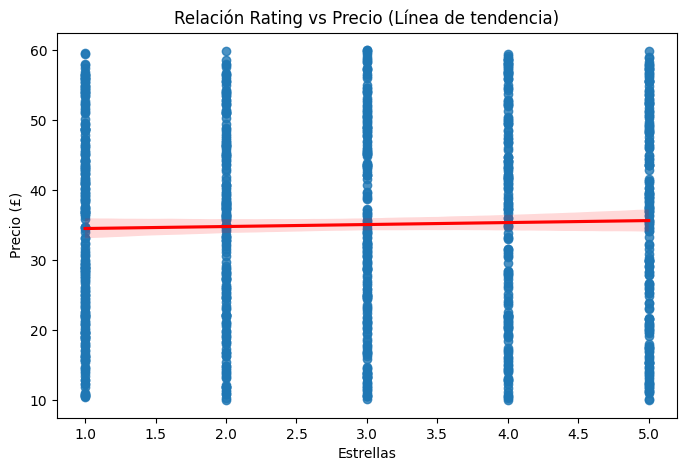

In [31]:
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.regplot(x='rating', y='precio_num', data=df, line_kws={"color": "red"})
plt.title("Relación Rating vs Precio (Línea de tendencia)")
plt.xlabel("Estrellas")
plt.ylabel("Precio (£)")
plt.show()

Este gráfico es la prueba visual definitiva de por qué salió 0.03 en la correlación. Se llama **Gráfico de Dispersión (Scatter Plot) con línea de regresión**.

Aquí están las claves para entender qué estamos viendo:
1. Los Puntos Azules    
Cada punto representa un libro.
* Su posición horizontal es el Rating (de 1 a 5 estrellas).
* Su posición vertical es el Precio (de £10 a £60).
* ¿Qué notas? Que en cada "columna" de estrellas, los puntos cubren casi todo el rango de precios. Hay libros de 1 estrella que cuestan £60 y libros de 5 estrellas que cuestan £10. Los puntos están esparcidos uniformemente.

2. La Línea Roja (Línea de Tendencia)   
Esta línea intenta encontrar un patrón o "camino" entre los puntos.
* Si la línea fuera hacia arriba (diagonal): Significaría que a más estrellas, más caro el libro (correlación positiva).
* Si la línea fuera hacia abajo: Significaría que a más estrellas, más barato (correlación negativa).
* En el gráfico, la línea es **HORIZONTAL**: Una línea plana significa que el precio no cambia aunque cambien las estrellas. Por eso la correlación es casi cero ($0.03$). No hay pendiente, no hay tendencia.

3. La Sombra Rosada   
Esa área sombreada alrededor de la línea roja representa el Intervalo de Confianza.
* Como es un área delgada pero muy plana, nos dice que el modelo está muy seguro de que no hay relación. No hay "sorpresas" ni grupos de libros que rompan esa horizontalidad.

**Resumen**   
 Hemos trazado una línea de regresión sobre los datos de precio y rating. Como la pendiente de la línea roja es prácticamente cero (horizontal), queda visualmente demostrado que no hay una tendencia: tener mejores valoraciones no implica que el libro sea más caro en esta tienda.   
Es como intentar adivinar la estatura de alguien sabiendo su color de ojos: como no tiene nada que ver, la línea de tendencia sale plana.

### Consulta 4: Libros con máxima puntuación....¡y económicos!

Filtramos los libros que tienen 5 estrellas y están por debajo del precio medio.

In [32]:
precio_medio = df['precio_num'].mean()
mejores_ofertas = df[(df['rating'] == 5) & (df['precio_num'] < precio_medio)] # si queremos solo n número de libros, añadimos `.head(n)`
print(f"Libros de 5 estrellas por debajo de £{precio_medio:.2f}:")
print(mejores_ofertas[['titulo', 'precio_num']])

Libros de 5 estrellas por debajo de £35.07:
                                                titulo  precio_num
12                                         Set Me Free       17.46
14                           Rip it Up and Start Again       35.02
23                          Chase Me (Paris Nights #2)       25.27
24                                          Black Dust       34.53
30   The Four Agreements: A Practical Guide to Pers...       17.66
..                                                 ...         ...
933                                         The Haters       27.89
934                                  The Girl You Lost       12.29
993  Bleach, Vol. 1: Strawberry and the Soul Reaper...       34.65
997  A Spy's Devotion (The Regency Spies of London #1)       16.97
999                 1,000 Places to See Before You Die       26.08

[90 rows x 2 columns]


Si queremos los 10 libros más baratos de entre los que tienen 5 estrellas, podemos usar `nsmallest`.

In [33]:
precio_medio = df['precio_num'].mean()
mejores_ofertas = df[df['rating'] == 5].nsmallest(10, 'precio_num')
print(f"Libros de 5 estrellas por debajo de £{precio_medio:.2f}:")
print(mejores_ofertas[['titulo', 'precio_num']])

Libros de 5 estrellas por debajo de £35.07:
                                                titulo  precio_num
638                         An Abundance of Katherines       10.00
302                               Greek Mythic History       10.23
590  The Power Greens Cookbook: 140 Delicious Super...       11.05
316                                 Dear Mr. Knightley       11.21
601                                The Darkest Corners       11.33
521  Naturally Lean: 125 Nourishing Gluten-Free, Pl...       11.38
900           Fruits Basket, Vol. 2 (Fruits Basket #2)       11.64
277              Old School (Diary of a Wimpy Kid #10)       11.83
261  Superman Vol. 1: Before Truth (Superman by Gen...       11.89
535   Every Heart a Doorway (Every Heart A Doorway #1)       12.16


### Consulta 5: Los 10 libros "Premium" (o con precios más altos) y gráfico de Piruleta

In [34]:
top_premium = df.nlargest(10, 'precio_num')
display(top_premium)

,titulo,precio,rating,stock,precio_num,longitud_titulo
648,The Perfect Play (Play by Play #1),Â£59.99,3,In stock,59.99,34
617,Last One Home (New Beginnings #1),Â£59.98,3,In stock,59.98,33
860,Civilization and Its Discontents,Â£59.95,2,In stock,59.95,32
560,The Barefoot Contessa Cookbook,Â£59.92,5,In stock,59.92,30
366,The Diary of a Young Girl,Â£59.90,3,In stock,59.90,25
657,The Bone Hunters (Lexy Vaughan & Steven Macaul...,Â£59.71,3,In stock,59.71,52
133,Thomas Jefferson and the Tripoli Pirates: The ...,Â£59.64,1,In stock,59.64,89
387,Boar Island (Anna Pigeon #19),Â£59.48,3,In stock,59.48,29
393,The Improbability of Love,Â£59.45,1,In stock,59.45,25
549,The Man Who Mistook His Wife for a Hat and Oth...,Â£59.45,4,In stock,59.45,63


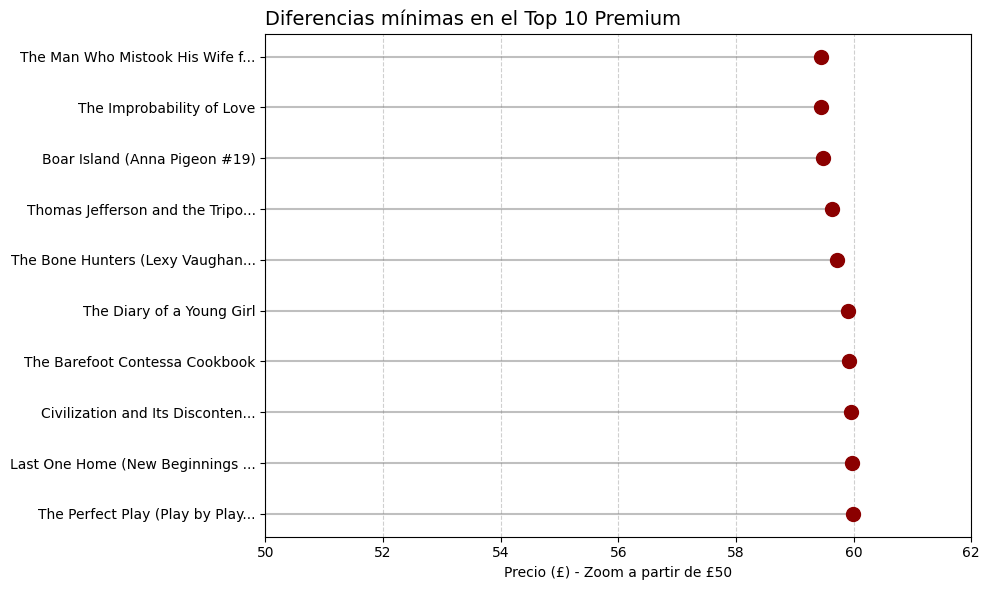

In [39]:
# Creamos una versión corta de los títulos para que no ocupen tanto y se vean las barras
titulos_cortos = [t[:30] + '...' if len(t) > 30 else t for t in top_premium['titulo']]

plt.figure(figsize=(10, 6))

# Usamos un color degradado para que no sea un bloque sólido
colors = plt.cm.Reds(pd.Series(range(10, 0, -1)) / 10)

plt.hlines(y=titulos_cortos, xmin=50, xmax=top_premium['precio_num'], color='gray', alpha=0.5)
plt.plot(top_premium['precio_num'], titulos_cortos, "o", markersize=10, color='darkred')

plt.title("Diferencias mínimas en el Top 10 Premium", loc='left', fontsize=14)
plt.xlabel("Precio (£) - Zoom a partir de £50")
plt.xlim(50, 62) # HACEMOS ZOOM para ver las pequeñas diferencias
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

En el gráfico de Piruleta o Lollipop Chart, lo que hicimo fue comenzar el eje X en £50 en lugar de 0, y así podemos apreciar mejor las sutiles diferencias en los precios que lo que nos puede mostrar un gráfico de barras.